# IAT 461 — Assignment 4: Client Peer Project

## Context

### Entity

Kosima Production is a fictional video game development and player research company. The company studies player behaviour and public feedback to support decisions about game updates, technical improvements, and community communication. For this project, Kosima Production is examining Steam reviews of Cyberpunk 2077, an open-world role-playing game with a large and active player community. The company wants to understand why some players leave negative reviews and which concerns should receive the most attention.

### Business Context and Strategic Options

Cyberpunk 2077 has received a large number of Steam reviews containing feedback about technical performance, gameplay systems, story content, controls, and other parts of the player experience. The overall review score shows whether players recommend the game, but it does not clearly explain the reasons behind negative reviews.

Kosima Production is considering three possible strategies:
- Option A: Increase advertising and promotional activities to attract more players.
- Option B: Improve general community communication by publishing more announcements, development updates, and responses to player questions.
- Option C: Analyze negative Steam reviews to discover the technical and gameplay concerns that players mention most often, then use these findings to prioritize future improvements.


### Task

#### Phase 1, EDA and Strategy Validation

Using the structured review data, examine player recommendation outcomes, playtime, helpfulness votes, review dates, purchase status, reviewer experience, and other available variables. Determine whether negative reviews are mainly connected to limited communication, certain types of players, particular time periods, or repeated technical and gameplay concerns. Use the results to evaluate Options A, B, and C and identify which strategy is best supported by the data.

#### Phase 2, Data Science Implementation

Assuming Kosima Production proceeds with Option C, group the English-language negative reviews according to their underlying complaint themes. The analysis should not begin with a predefined list of issue categories. Instead, the themes should be discovered from similarities in the language used in the reviews.

After creating the groups, compare them using the number of reviews, percentage of negative reviews, median player playtime, review length, helpfulness votes, purchase status, and reviewer experience. Use these comparisons to determine which complaint themes should receive the highest priority.


## Imports

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk

from spacy.lang.en.stop_words import STOP_WORDS
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

# classification + clustering

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Initial Steps

### Loading Dataset

We will first take a look at the dataset our client provided for us.

In [11]:
df = pd.read_csv("Cyberpunk_2077_English_Reviews_Final.csv")
df.head(5)

,ReviewID,SteamID,Rating,Review,Date Posted,Hours Played,Voted Helpful,Received for Free,Update,Detected Language
0,81918897,Rommel,Recommended,"""Hᴇ's ғᴜᴄᴋᴇᴅ ɪɴ ᴛʜᴇ ʜᴇᴀᴅ, ᴛʜᴇ ᴡᴏʀʟᴅ's ғᴜᴄᴋᴇᴅ ɪ...",12/9/2020,401.5,22,False,Release,en
1,81918903,76561198038931832,Recommended,It's a city of dreams... and I'm a big dreamer.,12/9/2020,247.6,710,True,Release,en
2,81918912,limbo97,Recommended,Obligatory It's breathtaking!A wonderful sci-f...,12/9/2020,8.8,19,False,Release,en
3,81918918,sn1ffla,Not Recommended,"Bigot developerTo clarify, I got this game fro...",12/9/2020,86.1,18,True,Release,en
4,81918924,MeliGL,Recommended,Still waiting to be able to play.Edit: I'm not...,12/9/2020,34.9,0,False,Release,en


### Inspecting the Data

Next, we'll be inspecting the data for their types, structure, and any missing values.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ReviewID           365388 non-null  int64 
 1   SteamID            365388 non-null  object
 2   Rating             365388 non-null  object
 3   Review             362569 non-null  object
 4   Date Posted        365388 non-null  object
 5   Hours Played       365388 non-null  object
 6   Voted Helpful      365388 non-null  object
 7   Received for Free  365388 non-null  bool  
 8   Update             365388 non-null  object
 9   Detected Language  365388 non-null  object
dtypes: bool(1), int64(1), object(8)
memory usage: 25.4+ MB


Seems like we're only missing a few thousand reviews. We'll keep these in for now as the extra data is helpful and filter them out later during our text processing.

In [16]:
df.sample(5)

,ReviewID,SteamID,Rating,Review,Date Posted,Hours Played,Voted Helpful,Received for Free,Update,Detected Language
280238,136853217,76561198867572947,Recommended,It has its problems but it still amazing,4/17/2023,570.8,0,False,Patch 1.62,en
14439,81993413,76561199047493566,Recommended,was really impressed so far. one of the most a...,12/10/2020,6.8,0,False,Release,en
267154,129750602,76561198205679143,Recommended,Amazing story that did a fairly good job of ge...,12/30/2022,338.4,0,False,Patch 1.61,en
94964,82527237,76561198101317148,Recommended,"It's not the second coming of Christ, but it i...",12/16/2020,379.3,2,False,Hotfix 1.04,en
37305,82115396,krystakitsune,Recommended,"while yes, the game is a bit messy right now, ...",12/11/2020,123.2,4,False,Hotfix 1.04,en


Let's just make sure everything is in English:

In [18]:
df["Detected Language"].value_counts()

Detected Language
en    365388
Name: count, dtype: int64

And then looking at the balance of our ratings:

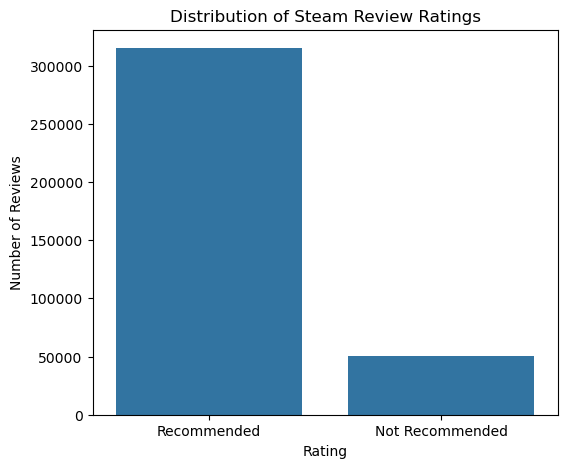

In [20]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Rating"
)

plt.title("Distribution of Steam Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [21]:
rating_percent = (
    df["Rating"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(rating_percent)

Rating
Recommended        86.21
Not Recommended    13.79
Name: proportion, dtype: float64


We are working with an unbalanced dataset.

### Data Conversion

Let's just quickly update the fields `Hours Played` and `Voted Helpful` to the right data types:

In [25]:
df["Hours Played"] = (
    df["Hours Played"]
      .str.replace(",", "")
      .astype(float)
)

df["Voted Helpful"] = (
    df["Voted Helpful"]
      .str.replace(",", "")
      .astype(int)
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ReviewID           365388 non-null  int64  
 1   SteamID            365388 non-null  object 
 2   Rating             365388 non-null  object 
 3   Review             362569 non-null  object 
 4   Date Posted        365388 non-null  object 
 5   Hours Played       365388 non-null  float64
 6   Voted Helpful      365388 non-null  int32  
 7   Received for Free  365388 non-null  bool   
 8   Update             365388 non-null  object 
 9   Detected Language  365388 non-null  object 
dtypes: bool(1), float64(1), int32(1), int64(1), object(6)
memory usage: 24.0+ MB


Since our brief wants us to:

> Determine whether negative reviews are mainly connected to limited communication, certain types of players, **particular time periods**, or repeated technical and gameplay concerns.

We'll go ahead and convert `Date Posted` to datetime in anticipation of working with dates.

In [27]:
df["Date Posted"] = pd.to_datetime(
    df["Date Posted"],
    format="mixed", # this dataset has mixed formats I had found
    errors="coerce"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365388 entries, 0 to 365387
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ReviewID           365388 non-null  int64         
 1   SteamID            365388 non-null  object        
 2   Rating             365388 non-null  object        
 3   Review             362569 non-null  object        
 4   Date Posted        365388 non-null  datetime64[ns]
 5   Hours Played       365388 non-null  float64       
 6   Voted Helpful      365388 non-null  int32         
 7   Received for Free  365388 non-null  bool          
 8   Update             365388 non-null  object        
 9   Detected Language  365388 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int32(1), int64(1), object(5)
memory usage: 24.0+ MB


We'll also quickly add some other useful date times:

In [29]:
df["Year"] = df["Date Posted"].dt.year
df["YearMonth"] = df["Date Posted"].dt.to_period("M")

monthly_reviews = (
    df.groupby("YearMonth")
      .size()
      .reset_index(name="Reviews")
)

print(monthly_reviews.head())

  YearMonth  Reviews
0   2020-12   148492
1   2021-01    21754
2   2021-02     5721
3   2021-03     4665
4   2021-04     3931


## Assumptions Log

Based on the given dataset and the task at hand, I continued on with the following assumptions:

**Hours Played is used as a proxy for "reviewer experience"**

The dataset doesn't contain a direct measure of "reviewer experience", so we are using `Hours Played`, which is a measure of experience with the game.

**Received for Free is used as a proxy for "purchase status"**

The dataset doesn't contain a direct measure of "purchase status" (eg. if they refunded the game, demoed, got on sale, etc.), so we are using `Received For Free`, which is the next closest thing to purchase status.

**Communication**

The dataset doesn't contain a direct measure of communication from the developers, like announcements, exposure to the playerbase, and player responses, so we will be basing it off of changes of sentiment over time instead, which I assume that developers continued a normal amount of communication to players.

**Advertising**

We are going to evaluate Option A indirectly through player characteristics and review outcomes as we do not have data on advertising or player-acquisition data.

These are all due to the limitations of the given dataset. 

**Quick Note about the Dataset:**

The proposal said that a smaller, 2,400-review sample of the dataset will be provided. However, I chose this larger dataset as we can draw more information for the EDA. For text analysis in Phase 2, I plan to filter it to a subset of the most recent reviews to make it relevant for complaint analysis and to save on computing.

## Phase 1: EDA and Strategy Validation

> Using the structured review data, examine player recommendation outcomes, playtime, helpfulness votes, review dates, purchase status, reviewer experience, and other available variables. Determine whether negative reviews are mainly connected to limited communication, certain types of players, particular time periods, or repeated technical and gameplay concerns. Use the results to evaluate Options A, B, and C and identify which strategy is best supported by the data.

### Review Timeline

Using the `Date Posted` field, we can just look through how reviews for the game look like throughout the months.

#### Reviews Over Time

First, let's get te total reviews over time.

In [39]:
monthly_reviews = (
    df.groupby("YearMonth")
      .size()
      .reset_index(name="Reviews")
)

monthly_reviews["YearMonth"] = monthly_reviews["YearMonth"].astype(str)

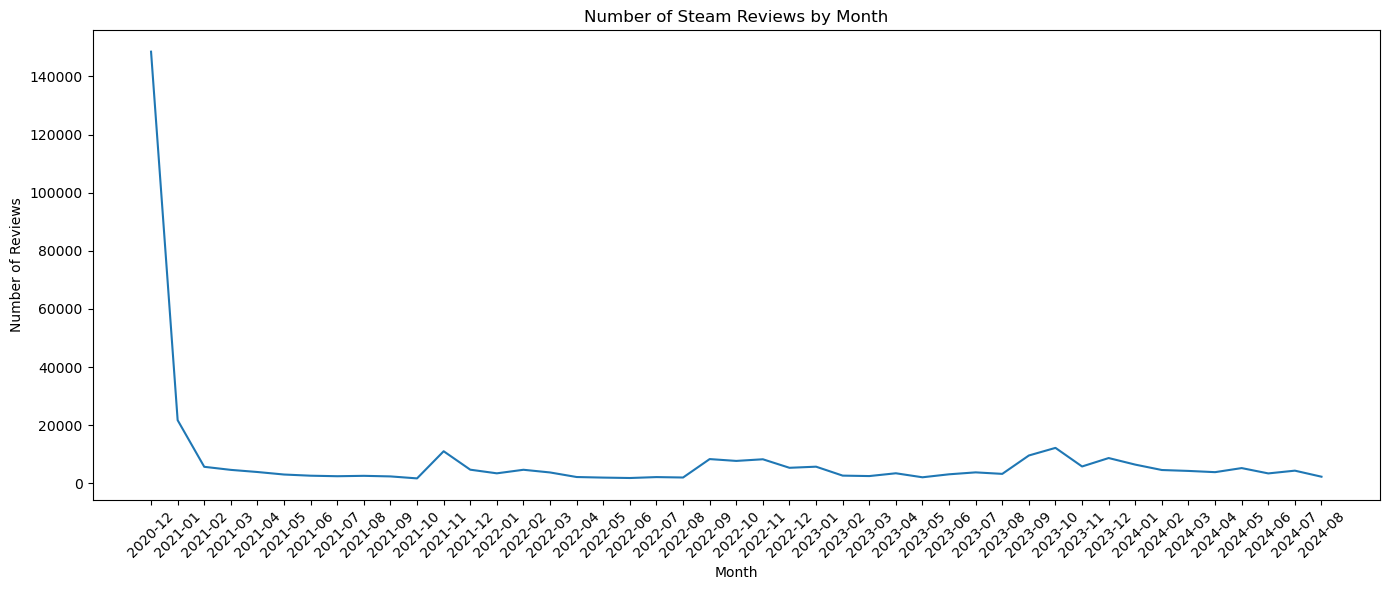

In [40]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_reviews["YearMonth"],
    monthly_reviews["Reviews"]
)

plt.xticks(rotation=45)

plt.title("Number of Steam Reviews by Month")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

This shows that most reviews were written after launch, and trends upwards around November 2021, August 2022, and October 2023. Let's take a look at what patch these are:

In [42]:
df.loc[df["YearMonth"] == "2021-11", "Update"].value_counts()

Update
Patch 1.31    11071
Name: count, dtype: int64

Comes after one of the ["most significant update for the game yet"](https://www.notebookcheck.net/Cyberpunk-2077-Patch-1-3-is-the-most-significant-update-for-the-game-yet-with-over-33-GB-of-fixes-changes-and-improvements.555775.0.html). 

In [44]:
df.loc[df["YearMonth"] == "2022-09", "Update"].value_counts()

Update
Patch 1.6     8120
Patch 1.52     256
Name: count, dtype: int64

This set of reviews come after the [Cyberpunk: Edgerunners](https://www.cyberpunk.net/en/news/45280/edgerunners-update-patch-1-6-list-of-changes) update. This is a separate anime based on the game that possibly brought in new players to the game.

In [46]:
df.loc[df["YearMonth"] == "2023-10", "Update"].value_counts()

Update
Patch 2.01    8070
Patch 2.0     2690
Patch 2.02    1470
Name: count, dtype: int64

This set of reviews come after the [2.0 updates](https://expertgamereviews.com/cyberpunk-2077-2-update-complete-guide/). We can take a closer look by checking the positive vs. negative reviews over time:

#### Positive vs Negative over time

In [49]:
monthly_rating = (
    df.groupby(["YearMonth", "Rating"])
      .size()
      .unstack(fill_value=0)
)

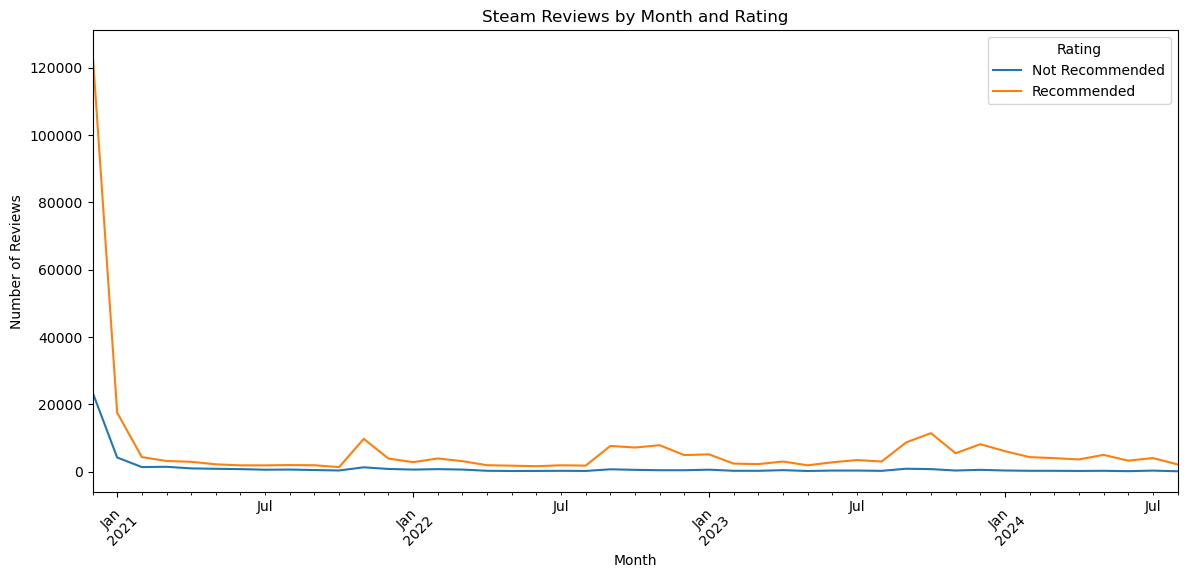

In [50]:
monthly_rating.plot(
    figsize=(14,6)
)

plt.title("Steam Reviews by Month and Rating")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

Overall, it looks like the negative reviews remained flat all throughout the time periods. There's a huge chunk at release, but the uptick in reviews seem to be positive in the ones we've identified above. Let's zoom in to take a closer look at the ratings:

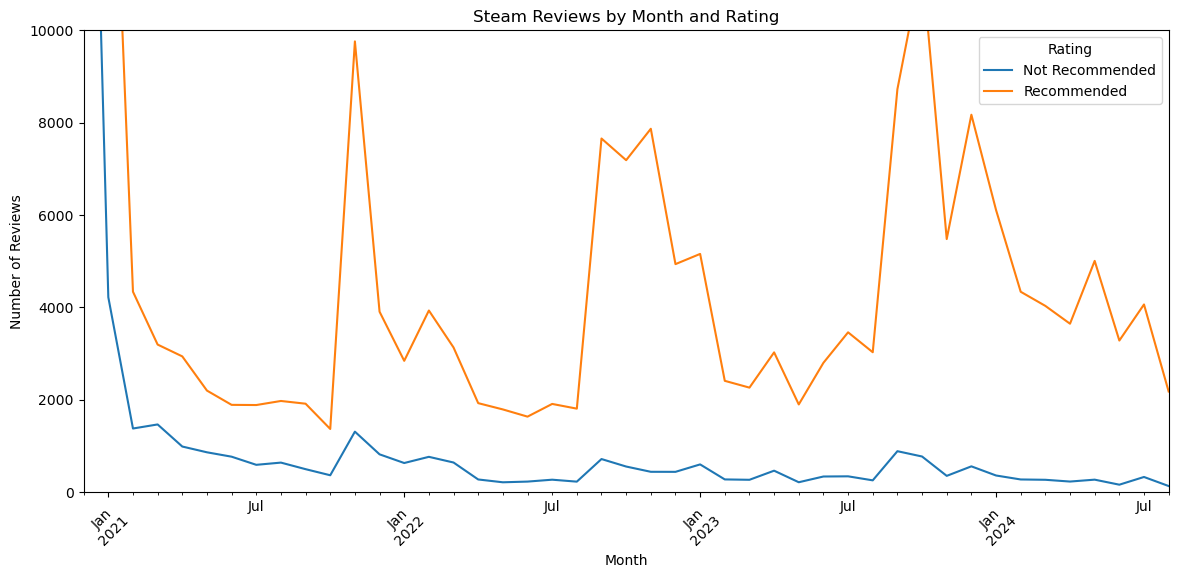

In [52]:
monthly_rating.plot(
    figsize=(14,6)
)

plt.title("Steam Reviews by Month and Rating")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.ylim(0, 10000) # set y limit to "zoom" in

plt.xticks(rotation=45)

plt.show()

Those trends in reviews we identified earlier (from certain updates) seem to be mostly positive reviews. Each wave of positive reviews come with a wave of negative reviews as well, however.

#### Percent of Negative Reviews

By looking at the percent of negative reviews to the rest of it, we can get a better picture of user sentiment throughout time.

In [55]:
monthly_counts = (
    df.groupby(["YearMonth", "Rating"])
      .size()
      .unstack(fill_value=0)
)

monthly_percent = monthly_counts.div(
    monthly_counts.sum(axis=1),
    axis=0
) * 100

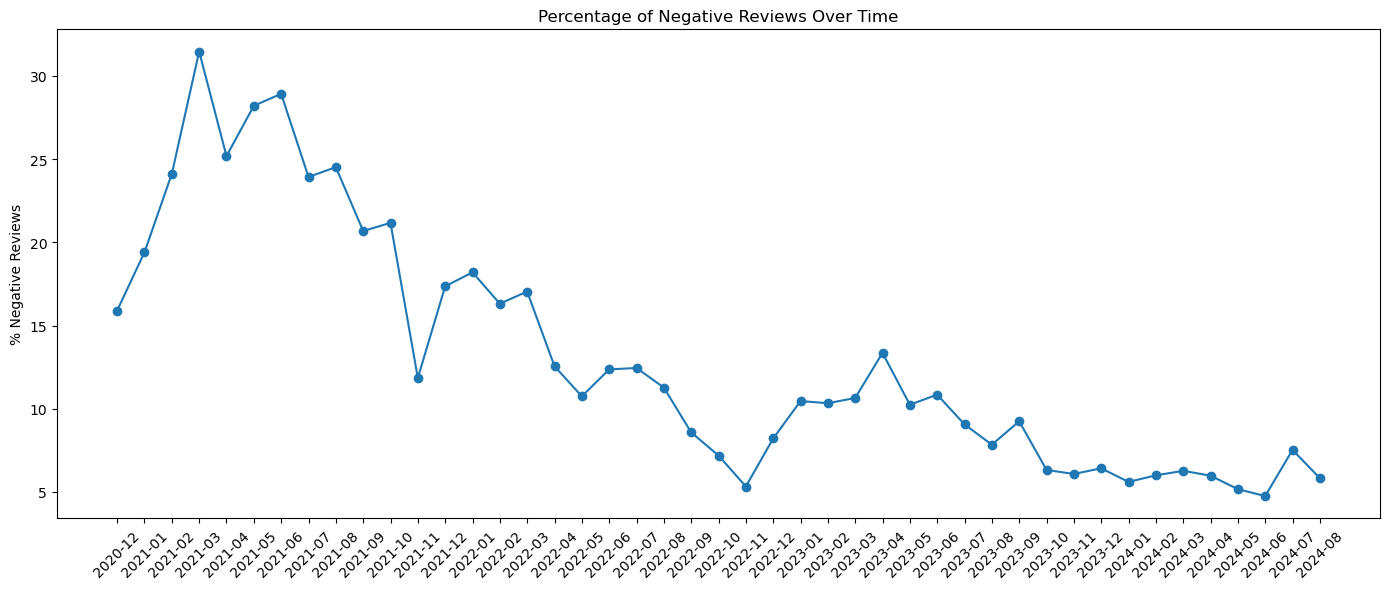

In [56]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_percent.index.astype(str),
    monthly_percent["Not Recommended"],
    marker="o"
)

plt.xticks(rotation=45)
plt.ylabel("% Negative Reviews")
plt.title("Percentage of Negative Reviews Over Time")
plt.tight_layout()
plt.show()

It looks like negative reviews (compared to positive reviews) percentage generally decrease over time with the exception of early release, December 2021, and May 2023. However, the graph above this one shows a more constant stream of negative reviews, meaning that rather than negative reviews dropping, positive reviews just overwhelm the percentages.

#### Interpretation and Analysis

Based on these findings, we see that negative reviews remain consistent throughout time, with the exception of major patches and releases (which end up stabilizing anyway). There were the most negative reviews upon launch, but generally trend downwards throughout time. With this in mind, let's evaluate the options so far:

**Option A - Advertising**: As negative reviews generally decrease over time, attracting more players would possibly result in more positive reviews. We can see this in the Cyberpunk: Edgerunners patch in Fall 2022. However, it is unclear whether or not attracting new players to the game would help us understand why some players leave negative reviews.

**Option B - Communication**: Our findings show that user sentiment to the game (through the percentage of Negative Reviews Over Time) decrease over time, especially after the hotfixes after major releases. It's likely that learning about bugs and fixing them right away lead to more player satisfaction, meaning we should consider Option B more closely.

**Option C - Complaint Analysis**: Unclear so far.

### Player Characteristics

We can take a look at the characteristics of the players (playtime & if they received the game for free).

#### Hours Played vs Rating

First, let's quickly just look at the summary statistics for `Hours Played`.

In [62]:
df.groupby("Rating")["Hours Played"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,90.597130,171.010862,0.0,21.1,56.0,112.1,16052.3
Recommended,315005.0,163.536008,264.924241,0.1,62.0,111.2,193.9,29823.0


As one would expect, there are less hours played for those who do not recommend the game. There's a median of 56 hours for those who do not recommend the game, while there's a median of 111.2 for those who do recommend the game. 

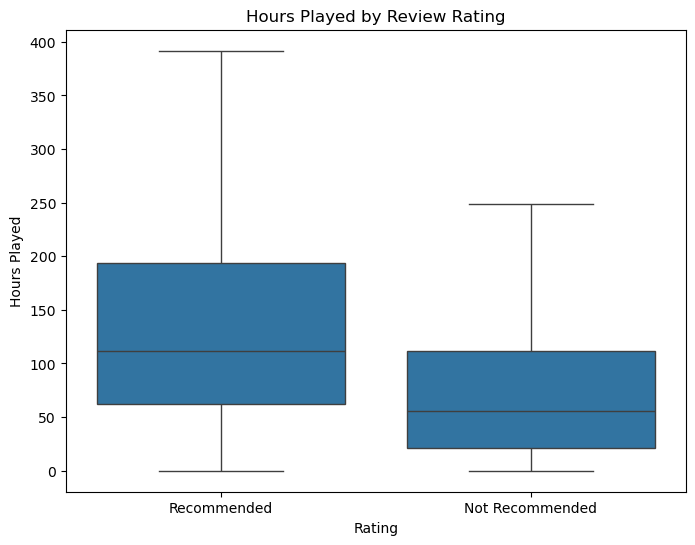

In [358]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Hours Played",
    showfliers=False # remove outliers to show the box more clearly
)

plt.title("Hours Played by Review Rating")
plt.ylabel("Hours Played")

plt.show()

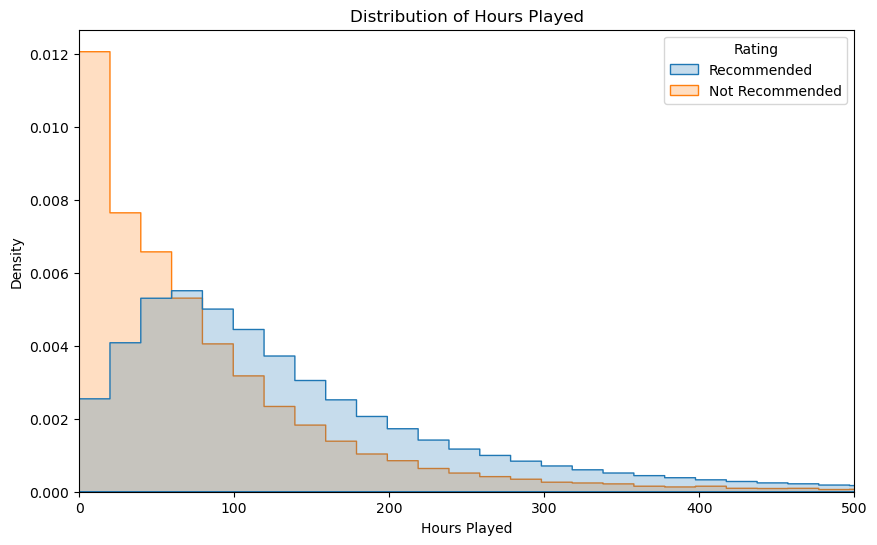

In [360]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Hours Played",
    hue="Rating",
    bins=1500,
    stat="density",
    common_norm=False,
    element="step"
)

plt.xlim(0,500)

plt.title("Distribution of Hours Played")

plt.show()

Above is a density plot of hours played vs. whether or not they recommend the game. As shown in the chart, more players who do not recommend the game tend to have lower playtimes, more specifically in the 0-60 hour mark. As players play more of the game, they tend to leave a more positive review.

Both distributions are right-skewed. This means that most players, regardless of rating, have low playtime.

#### Purchase Status / Received for Free

We can also take a look at each player's purchase status for this game. Do players who receive the game tend to leave a more favourable review?

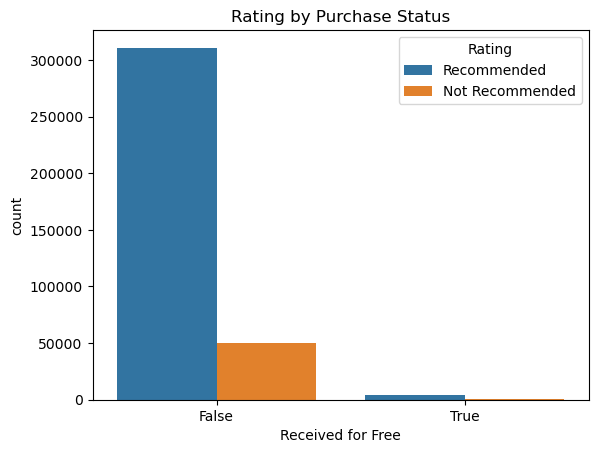

In [68]:
sns.countplot(
    data=df,
    x="Received for Free",
    hue="Rating"
)

plt.title("Rating by Purchase Status")
plt.show()

It's a bit hard to read, so we'll pivot to a percentage-based view of the data:

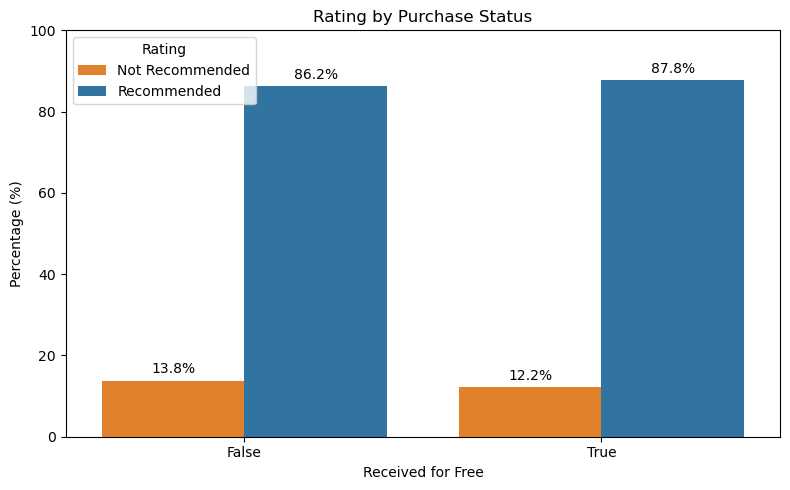

In [70]:
# Calculate percentages
percent_df = (
    pd.crosstab(
        df["Received for Free"],
        df["Rating"],
        normalize="index"
    ) * 100
).reset_index().melt(
    id_vars="Received for Free",
    var_name="Rating",
    value_name="Percentage"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=percent_df,
    x="Received for Free",
    y="Percentage",
    hue="Rating",
    palette=["tab:orange", "tab:blue"]  # Flipped colors
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.ylabel("Percentage (%)")
plt.xlabel("Received for Free")
plt.title("Rating by Purchase Status")
plt.ylim(0, 100)
plt.legend(title="Rating")

plt.tight_layout()
plt.show()

It seems that there isn't too much of a difference if a player received the game for free or not. There is only a 1.6% difference between the not recommended reviews out of the whole. 

#### Interpretation and Analysis

Based on these findings, we see that the distribution for playtime is right skewed, meaning that most players play under 100 hours. The distribution for those who do not recommend the game fall mostly between 0-60 hours, whereas those who do recommend the game fall mostly between 60-100 hours and in higher playtimes. We also find that there isn't an observable difference between purchase status or not whether or not they recommend the game or not in their reviews. With this in mind, let's evaluate the options so far:

**Option A: Advertising**: Not strongly supported, as negative reviews are more likely to come from players with lower playtime. Attracting more players could potentially result in more players encountering the same issues that lead to negative reviews. The lack of a noticeable difference based on whether or not players received the game for free suggests that price isn't a primary concern for the players. Therefore, increasing the number of players does not seem to address the problems that lead to negative reviews.

**Option B: Communication**: Improving communication also is not strongly supported. Although the data shows that there's a difference in playtime between those who leave positive and negative reviews, playtime alone doesn't indicate whether or not communication is the reason for this difference. Since purchase status doesn't seems to have a relationship whether or not the player gives a positive or a negative review, there isn't really much evidence that shows changing how the company communicates with the players would fix player dissatisfaction. 

**Option C: Complaint Analysis**: Most promising option, but seeing these player characteristics is not enough. The difference in playtime might mean that some players encounter problems relatively early in game, but we still would have no idea what those problems are. Checking out the language in the negative reviews might lead to more direct evidence about game issues.

### Review Characteristics

Next, we'll take a look at the the characteristics of the reviews (helpful votes, length, correlations, etc.).

#### Review Length

Longer reviews usually mean that the feedback is more detailed, while shorter ones might just be approval or disapproval. We can create this feature and compare between recommended and not recommended reviews.

In [76]:
# Create review length

df["Review Length"] = (
    df["Review"]
      .fillna("")
      .str.split()
      .str.len()
)

In [77]:
df.groupby("Rating")["Review Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,88.536213,168.149093,0.0,7.0,28.0,92.0,1572.0
Recommended,315005.0,44.353601,108.025052,0.0,2.0,11.0,38.0,2000.0


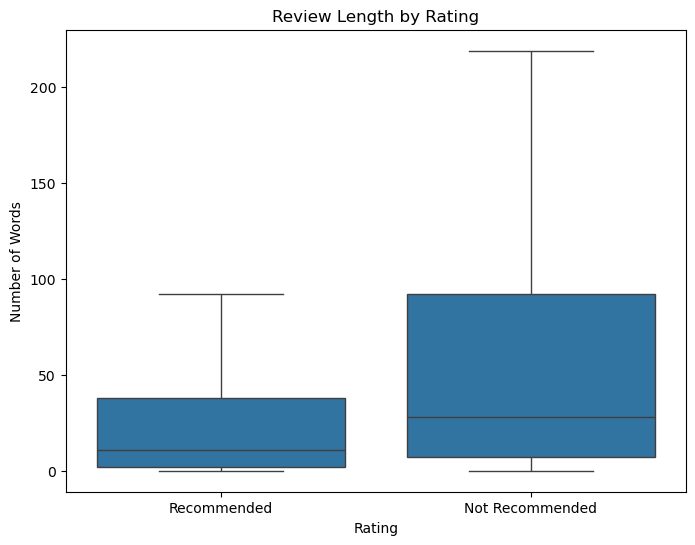

In [78]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Review Length",
    showfliers=False  # remove outliers to show the box more clearly
)

plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Words")

plt.show()

Looking at the distribution, it seems like it is right skewed. It seems that the recommended reviews are shorter in general with a lower average and median. This makes sense as negative reviews would provide more detailed explanations for their dissatisfaction of the game.

#### Helpful Votes

Taking a look at the reviews' helpful votes can let us know if they are useful or not.

In [81]:
df.groupby("Rating")["Voted Helpful"].describe()

,count,mean,std,min,25%,50%,75%,max
Rating,,,,,,,,
Not Recommended,50383.0,5.474009,125.068857,0.0,0.0,1.0,2.0,12367.0
Recommended,315005.0,1.561426,69.781851,0.0,0.0,0.0,1.0,20111.0


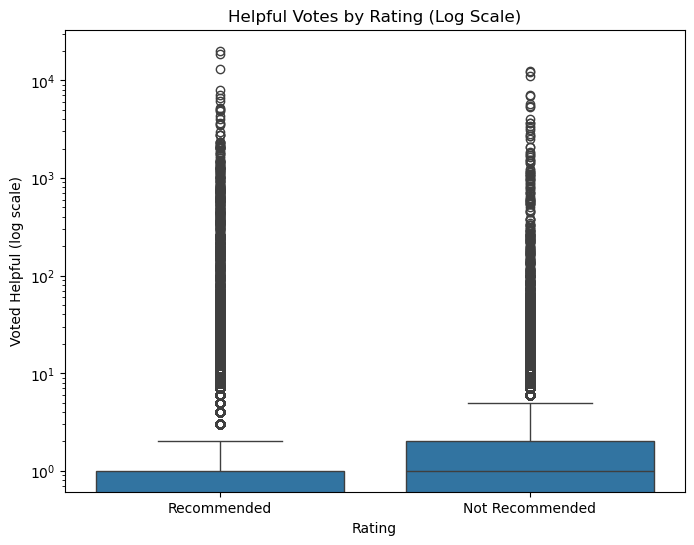

In [82]:
plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=df,
    x="Rating",
    y="Voted Helpful"
)

ax.set_yscale("log") # set to log scale to make it easier to read

plt.title("Helpful Votes by Rating (Log Scale)")
plt.ylabel("Voted Helpful (log scale)")
plt.show()

It seems that negative reviews receive more helpful votes on average, meaning that other players find these reviews more informative. However, a majority of the reviews are low anyway. 

#### Review Length vs Helpful Votes

We can take a look at whether or not helpful votes correlate with the review length. Does a longer review result in a more helpful review?

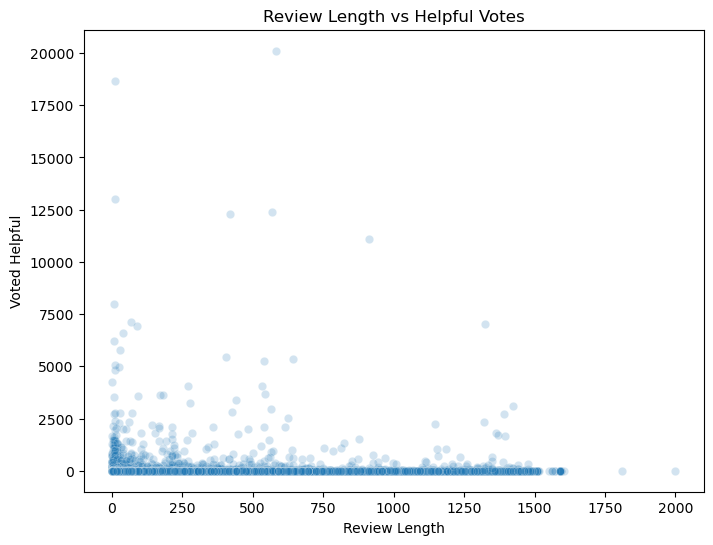

In [85]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Review Length",
    y="Voted Helpful",
    alpha=0.2
)

plt.title("Review Length vs Helpful Votes")

plt.show()

Doesn't look like much. Let's zoom in on that cluster at the bottom left to make sure:

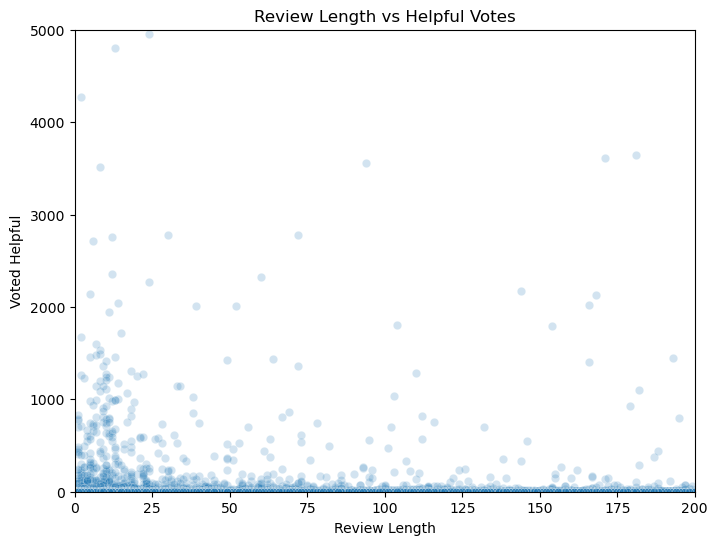

In [87]:
plot_df = df[
    (df["Voted Helpful"] <= 5000) &
    (df["Review Length"] <= 200)
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="Review Length",
    y="Voted Helpful",
    alpha=0.2
)

plt.title("Review Length vs Helpful Votes")
plt.xlim(0, 200)
plt.ylim(0, 5000)

plt.show()

There doesn't seem to be much correlation between the two as most reviews sit at 0 helpful votes. The top reviews seem to just be short and sweet. Out of curiosity, let's take a look:

In [89]:
df.loc[
    df["Voted Helpful"] > 12000,
    ["Voted Helpful", "Review"]
].sort_values("Voted Helpful", ascending=False)

,Voted Helpful,Review
4033,20111,DOWNLOAD THE NVIDIA GAME READY DRIVERS FOR THE...
94,18652,They made a 18+ gameThey also waited for every...
131251,13022,Just remember:Angel is a dude.Skye is a chick....
5122,12367,All the negative reviews thus far are about th...
176883,12286,Everyone complained about the bugs and glitche...


That's a very helpful top review.

#### Correlation between Numeric Features

Now let's just take in all of the numeric features and just look at the correlation matrix:

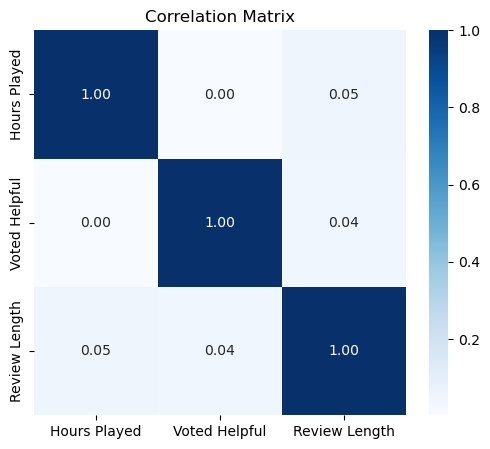

In [92]:
numeric = df[[
    "Hours Played",
    "Voted Helpful",
    "Review Length"
]]

corr = numeric.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

There does not seem to be a correlation whatsoever between `Hours Played`, `Voted Helpful`, and `Review Length`.

#### Interpretation and Analysis

Based on these findings, we see that there is an increase in review length for negative reviews than positive ones, probably due to the fact that these negative reviews have more to say than the positive ones. We also find that there are litle to no correlation between `Hours Played`, `Voted Helpful`, and `Review Length`. This information doesn't really do much for either of the first two options, but since the negative reviews are more detailed/lengthy, we can have much more to work with for Option C if we decide to go with it.

### Negative Review Text

To get started on determining if Option C is viable, we need to do a bit of NLP. We need to see if there are any recurring complaint themes that are worth analyzing.

In [97]:
# Get the negative reviews that aren't empty 

negative_reviews = df[(df["Rating"] == "Not Recommended") & (df["Review"].notna())].copy()

print(len(negative_reviews))

50234


We have 50234 total reviews we can work with.

#### Text Preprocessing

In [100]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [
        word for word in text.split()
        if word not in stop_words
    ]
    return words

In [101]:
negative_reviews["tokens"] = (
    negative_reviews["Review"]
    .apply(preprocess)
)

#### Text Processing

Using nltk and regular expressions and spacy and custom stopwords (shoutout to my LING special topics class that we did NLP in), we can get the 20 most common words in our negative reviews.

I had updated the stopwords list as I went through with this section. The following words in the stopword list are words I thought were unhelpful to our purpose here. Through this filtering, I was able to get more helpful results.

In [103]:
custom_stopwords = {
    "game", "games", "play", "played", "playing",
    "player", "players", "steam",
    "like", "get", "got", "one",
    # other terms I found would help narrow down the search
    "cd", "project", "projekt", "red", "reddit", 
    "youtube", "www", "com", "http", "https",
    "cyberpunk", "keanu", "deus", "theft",
    "crashedgame", "gta", "fallout",
    # I seem to not have done my tokenizing correctly so I just added the contractions into my stopwords
    "t", "s", "m", "ve", "re", "ll", "d",
    "don", "doesn", "didn", "isn", "aren",
    "wasn", "weren", "won", "would", "could",
    "also", "really", "even"
}

stop_words = list(STOP_WORDS | custom_stopwords)

#### Word Counts

In [105]:
all_words = [
    word
    for tokens in negative_reviews["tokens"]
    for word in tokens
    if word not in stop_words
]

word_counts = Counter(all_words)

word_counts.most_common(20)

[('story', 17246),
 ('bugs', 17219),
 ('good', 12205),
 ('time', 11879),
 ('world', 10909),
 ('character', 7641),
 ('bad', 7537),
 ('hours', 6885),
 ('feels', 6620),
 ('way', 6501),
 ('cdpr', 6464),
 ('city', 6360),
 ('feel', 6316),
 ('better', 6289),
 ('ai', 5842),
 ('fun', 5799),
 ('lot', 5766),
 ('people', 5759),
 ('years', 5687),
 ('gameplay', 5677)]

There are some interesting topics to look into like "story", "world", or "ai", but it doesn't tell us much. We'll be able to learn more if we looked at the bigrams:

#### Bigrams

In [108]:
# Get bigrams
vectorizer = CountVectorizer(
    stop_words=stop_words,
    ngram_range=(2,2)
)

X = vectorizer.fit_transform(
    negative_reviews["Review"]
)

counts = X.sum(axis=0).A1

bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), counts),
    key=lambda x: x[1],
    reverse=True
)

bigrams[:10]

[('open world', 4037),
 ('main story', 2419),
 ('night city', 2189),
 ('current state', 1309),
 ('bugs glitches', 1091),
 ('breaking bugs', 872),
 ('early access', 810),
 ('buggy mess', 769),
 ('bugs bugs', 759),
 ('story line', 754)]

We have topics like "open world", "main story", and "breaking bugs" (I had put the word "game" into the stop words"). If we put the bigrams into a word cloud it will be easier to visualize the different terms we got from the reviews:

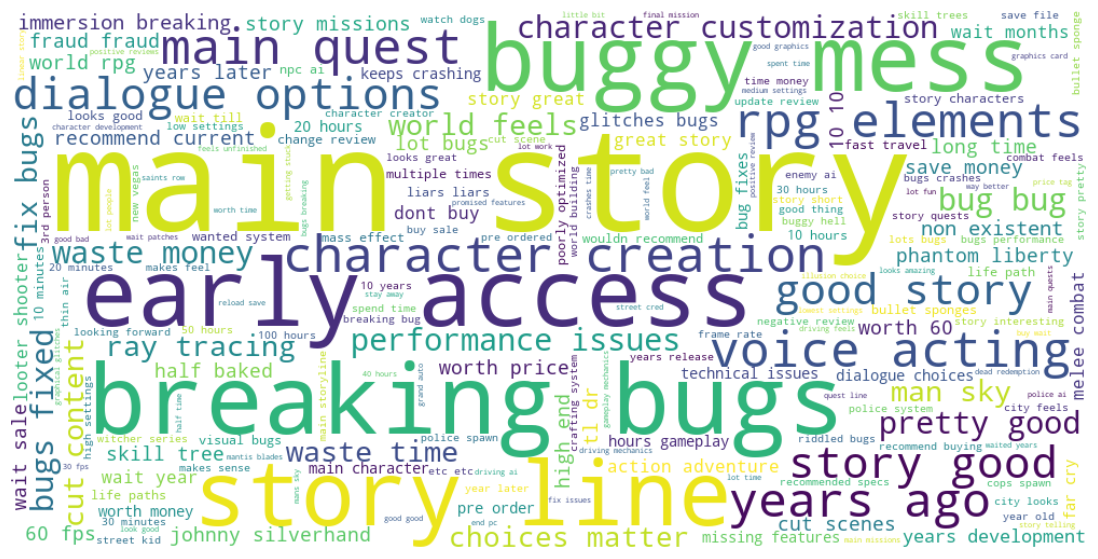

In [110]:
# Remove these phrases to not show on the wordcloud
phrases_to_remove = {
    "open world",
    "bugs glitches",
    "bugs bugs",
    "night city",
    "current state",
    "trash trash"
}

bigrams_filtered = [
    (phrase, count)
    for phrase, count in bigrams
    if phrase not in phrases_to_remove
]

# Bigrams to a dictionary
bigram_freq = dict(bigrams_filtered)

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(bigram_freq)

# Display
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

We have more descriptive topics like "wait sale", "waste money", "save money", or "immersion breaking", etc. It's clear that there are at least a few topics we can group them into. Let's also look at the trigrams while we're here:

#### Trigrams

In [113]:
# Get trigrams
vectorizer = CountVectorizer(
    stop_words=stop_words,
    ngram_range=(3,3),
)

X = vectorizer.fit_transform(
    negative_reviews["Review"]
)

counts = X.sum(axis=0).A1

trigrams = sorted(
    zip(vectorizer.get_feature_names_out(), counts),
    key=lambda x: x[1],
    reverse=True
)

trigrams[:10]

[('trash trash trash', 736),
 ('bugs bugs bugs', 449),
 ('bug bug bug', 415),
 ('open world rpg', 369),
 ('fraud fraud fraud', 334),
 ('recommend current state', 314),
 ('liars liars liars', 254),
 ('main story line', 246),
 ('bugs performance issues', 148),
 ('enemies bullet sponges', 137)]

These trigrams are much more negative. We'll update our phrases to remove variable with the unhelpful trigrams. We do have the term "enemies bullet sponges" which suggest that enemies feel like they have too much health, and "bugs performance issues" which relate to an unoptimized gaming experience. Let's look at the wordcloud:

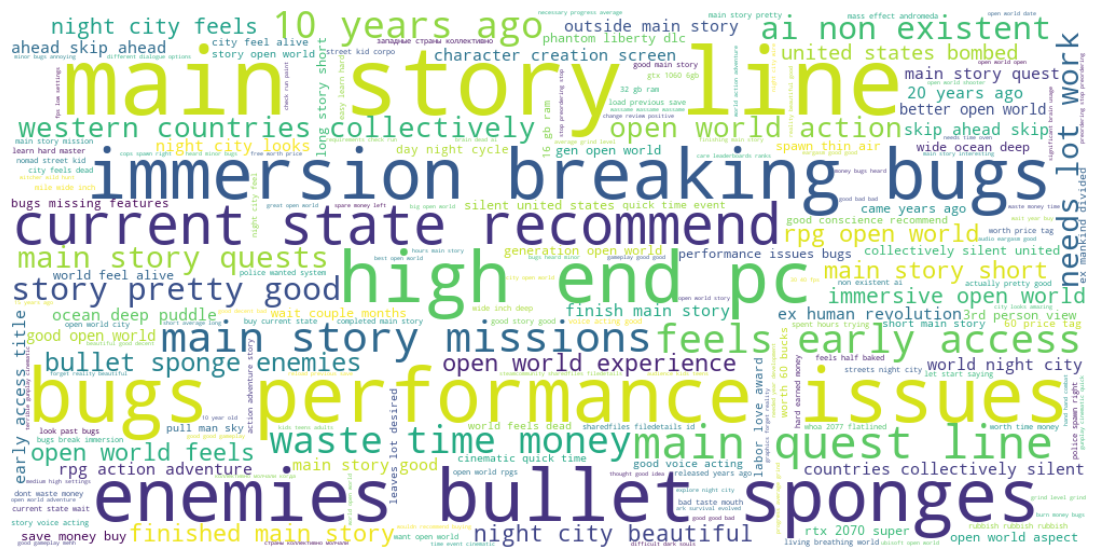

In [115]:
# Remove these phrases to not show on the wordcloud
phrases_to_remove = {
    "bugs bugs bugs",
    "recommend current state",
    "fraud fraud fraud",
    "open world rpg",
    "etc etc etc",
    "bla bla bla",
    "liars liars liars",
    "trash trash trash",
    "crash crash crash",
    "hate hate hate",
    "brokenits brokenits brokenits",
    "iti hate iti",
    "hate iti hate",
    "bug bug bug"
}

trigrams_filtered = [
    (phrase, count)
    for phrase, count in trigrams
    if phrase not in phrases_to_remove
]

# Trigrams into a dictionary
trigram_freq = dict(trigrams_filtered)

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(trigram_freq)

# Display
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

After filtering out the more unhelpful terms, we see a clearer picture of certain issues within the negative reviews. We have phrases like "bugs performace issues", "enemies bullet sponges", or "immersion breaking bugs" that clearly state certain issues players have with the game.

#### Interpretation and Analysis

Based on these findings, we see that there are a few topics we can look into when it comes to NLP and clustering. With phrases like "bugs performance issues", "enemies bullet sponges", or "immersion breaking bugs" for the trigrams, and "wait sale", "waste money", "save money" from the bigrams, it's clear that there are at least problems with performance issues, immersion, enemy health balancing, and pricing. These findings support Option C, the complaint analysis, as there are clear topics we can further analyze and group into to find out why players leave negative reviews and which ones need the most attention.

### Summary / Final Recommendation

Overall, the findings most strongly supports **Option C, which is to analyze negative Steam reviews to identify and prioritize recurring player concerns**. The EDA shows that negative reviews are more prevalent to those players with lower playtime, while positive reviews tend to come from players with more playtime. However, purchase status doesn't quite show a noticeable relationship to whether or not a player recommends the game or not, meaning that players' dissatisfaction for the game is not primarily explained by whether players got the game for free or not. The findings also show that negative reviews are generally longer than positive reviews, meaning that these provide more detailed text that can be used to identify the reasons behind player dissatisfactions with the game.

The review timeline shows that negative reviews were the most common during launch and major releases, followed by decreases after subsequent patches and hotfixes. This provides some support for **Option B**, as communication, responses, and fixes to the problems after these complaints may have contributed to player satisfaction. However, the data that was provided cannot confirm this as we don't have the information about developer communication or player exposure to announcements.

**Option A**, which is to increase advertising to attract newer players, is the least supported by the EDA. Although negative reviews generally decrease over time, the data doesn't show that attracting more players would address why players leave negative reviews. In fact, the concentration of negative reviews among the lower-playtime players suggests that players encounter problems early onto their gaming experience. Bringing in more players before understanding these problems could result in exposing this new playbase to the same issues.

**Option C** shows to be the best next step as it addresses the information we need the most: why players are dissastified. Initial NLP analysis found recurring phrases that relates to performance, bugs, immersion, enemy balancing, and pricing. By grouping and comparing these phrases from the negative reviews, Kosima Production will be able to find out what the major pain points/complaints are from the playbase, and determine which issues should receive the highest priority.

## Short Progress Report (MILESTONE 1)

Went through the data extensively. Changing my approach to the assignment from:
> for Option A, I plan to look at newer-player reviews (lower playtime etc.) and see what the sentiment is, while for Option B, I plan to look at older-player reviews (inverse of above). For option C, using NLP to figure out common words that the negative reviews have.

to a more holistic view of the data and drawing conclusions from each of these parts:
1. Timeline of the Reviews (looking at the dates to figure out if there are any trends in reviews at certain times)
2. Player Characteristics (looking at reviewers' statistics, their playtime and whether or not they received the game for free and compare it to their rating)
3. Review Characteristics (looking into review length, how helpful other people find their review, and general correlations between features)
4. Negative Review Text Processing (looking to see if there are any glaring common themes in the negative reviews to strictly see if Option C is viable)

Based on my findings from the EDA:
- Review sentiment: Negative reviews are more concentrated among players with lower playtime, while recommended reviews tend to come from players with higher playtime. Purchase status doesn't show a noticeable difference in recommendation outcomes.
- Review characteristics: Negative reviews tend to be longer than positive reviews, providing more detailed text that can be analyzed for recurring concerns. There are no strong observable correlations between playtime, helpfulness votes, and review length.
- Review timeline: Negative reviews are most prominent around the game's launch and major releases, all while negative reviews generally decrease after the following patches and hotfixes. This suggests that addressing problems may be associated with improved player sentiment, although the dataset doesn't have enough information to confirm that communication or patches directly caused these changes.
- Initial text analysis: Common words and phrases in negative reviews suggest recurring concerns related to bugs, performance, immersion, enemy balancing, and value/pricing. These show that negative reviews contain complaint themes that we can group up.

See above for the final recommendation.

For Phase 2, I will be taking an unsupervised approach. I'll be converting the negative reviews to numerical text representations and cluster it based on the similarities. Will use TD-IDF clustering.

## Phase 2: Data Science Implementation

> Assuming Kosima Production proceeds with Option C, group the English-language negative reviews according to their underlying complaint themes. The analysis should not begin with a predefined list of issue categories. Instead, the themes should be discovered from similarities in the language used in the reviews.
>
> After creating the groups, compare them using the number of reviews, percentage of negative reviews, median player playtime, review length, helpfulness votes, purchase status, and reviewer experience. Use these comparisons to determine which complaint themes should receive the highest priority.

We will be continuing onto Phase 2 with the intent of using TD-IDF and K-Means Clustering.

### Preprocess Text

We will re-preprocess our text in order to prepare it for TD-IDF and K-Means Clustering. Once again, we'll get all of the negative reviews that are not empty. We will also only take the reviews within the last 10 months (chosen based on the 'plateauing' of the percentage of the negative reviews from our EDA) into consideration as these are the more recent issues that the company would need to address:

In [125]:
phase2 = df[
    (df["Rating"] == "Not Recommended") &
    (df["Review"].notna()) &
    (df["Date Posted"] >= "2023-10-01")
].copy()

phase2[["Review", "Hours Played"]].head()

,Review,Hours Played
303884,the game is awful now after they did 2.0. update.,2.7
303887,"♥♥♥♥♥♥♥ game, still buggy as ♥♥♥♥ and crashes ...",1.8
303918,"Got the game because I figured you know, its b...",84.4
303926,You want me to gift subscriptions on Twitch to...,233.7
303929,getting softlocked from progressing a main sto...,198.7


We update our stopwords from scratch as I play around with the output. I found that these were the ones that gave the most useful outputs.

In [127]:
stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "game", "games",
    "play", "played",
    "playing", "get", "got", "one",
    "would", "could", "also",
}

stop_words = stop_words.union(custom_stopwords)

negation_words = {
    "no", "nor", "not", "never", "neither"
}

stop_words = stop_words - negation_words

Slight change from our old `preprocess` function that created a list to instead create a string instead of an object:

In [129]:
def preprocess_text(text):
    # Insert space between lowercase-uppercase transitions
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Split into words
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [130]:
phase2["Clean Review"] = phase2["Review"].apply(preprocess_text)
phase2["Clean Review"]

303884                                         awful update
303887    still buggy crashes no reason better recommend...
303918    figured know couple years new dlc supposed fix...
303926    want gift subscriptions twitch weapon ingame h...
303929    getting softlocked progressing main story miss...
                                ...                        
365320    great story garbage combat system bought disco...
365355    type bullet sponges enemies paper thing player...
365359                                          cyberglitch
365375    boring honestly ive playeing minutes minutes hard
365377    unplayable since car combat update hours new s...
Name: Clean Review, Length: 3720, dtype: object

Let's just quickly take a look at the distribution of the cleaned reviews:

In [132]:
phase2["Clean Review"].str.split().str.len().describe()

count    3720.000000
mean       34.088710
std        62.627957
min         0.000000
25%         4.000000
50%        14.000000
75%        37.000000
max       677.000000
Name: Clean Review, dtype: float64

I'll omit the ones that are short (<3) because these ones don't hold as much value.

In [134]:
phase2["Clean Word Count"] = (
    phase2["Clean Review"].str.split().str.len()
)

phase2_cluster = phase2[
    phase2["Clean Word Count"] >= 3
].copy()

In [135]:
print("Original negative English reviews:", len(phase2))
print("Reviews used for clustering:", len(phase2_cluster))

Original negative English reviews: 3720
Reviews used for clustering: 3135


We shaved off around 600 reviews for clustering. Let's just double check what our clean reviews look like:

In [137]:
phase2_cluster[
    ["Review", "Clean Review"]
].head(10)

,Review,Clean Review
303887,"♥♥♥♥♥♥♥ game, still buggy as ♥♥♥♥ and crashes ...",still buggy crashes no reason better recommend...
303918,"Got the game because I figured you know, its b...",figured know couple years new dlc supposed fix...
303926,You want me to gift subscriptions on Twitch to...,want gift subscriptions twitch weapon ingame h...
303929,getting softlocked from progressing a main sto...,getting softlocked progressing main story miss...
303934,Had this game a while and before the 2.0 updat...,update worked well since update dlss become un...
303965,Would love if i could even get past the first ...,love even past first mission saving lady tells...
304000,I tried the new 2.0 patch. OMG all i have to s...,tried new patch omg say mess bugs bugs bugs cr...
304003,EDIT 2: I think many people either didn't see ...,edit think many people either see trailers ann...
304022,Leaving a negative review because they have ju...,leaving negative review made sit captchas sign...
304025,Stupid Johnny Glitch still not fixed after 3 y...,stupid johnny glitch still not fixed years pos...


Looks good! Let's also check what our most common words are before we cluster.

In [139]:
all_words = " ".join(
    phase2_cluster["Clean Review"]
).split()

word_counts = Counter(all_words)

word_counts.most_common(30)

[('not', 2024),
 ('like', 1487),
 ('still', 1090),
 ('even', 1087),
 ('no', 991),
 ('story', 906),
 ('time', 815),
 ('good', 678),
 ('really', 628),
 ('bugs', 579),
 ('hours', 508),
 ('cyberpunk', 488),
 ('much', 487),
 ('years', 470),
 ('world', 455),
 ('make', 454),
 ('every', 452),
 ('way', 426),
 ('many', 416),
 ('bad', 410),
 ('crashes', 402),
 ('first', 399),
 ('people', 398),
 ('feels', 398),
 ('gameplay', 392),
 ('character', 389),
 ('fun', 388),
 ('update', 381),
 ('new', 374),
 ('boring', 370)]

### TD-IDF

We will continue with TD-IDF. I decided to limit the ngrams to bigrams as setting the max to 3 resulted in worse results. I had tested multiple values for `min_df` and `max_df` and found that `min_df = 4` and `max_df = 0.90` yielded the most useful clusters.

In [142]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90
)

X_tfidf = vectorizer.fit_transform(
    phase2_cluster["Clean Review"]
)

print(f"Shape: {X_tfidf.shape}")
print(f"Non-zero values: {X_tfidf.nnz}")

Shape: (3135, 8418)
Non-zero values: 119572


We went from 52000 total entries to working with only 3135 entries. 4370 features with only 106114 non zero values. Let's just quickly take a look at some of these features:

In [144]:
features = vectorizer.get_feature_names_out()

# Removing terms that I see show up very frequently that have no use to us
features_to_remove = {
    # "baby", "sweet baby", "sweet", "sbi"
    # "lights" # common word throughout all themes
}

keep = ~np.isin(features, list(features_to_remove))

X_tfidf_clean = X_tfidf[:, keep]

features_clean = features[keep]

print(X_tfidf.shape)
print(X_tfidf_clean.shape)

print(
    np.random.choice(features_clean, 50, replace=False)
)

(3135, 8418)
(3135, 8418)
['seemed like' 'stay away' 'little bugs' 'hundreds hours' 'buggy'
 'relevant' 'imagination' 'keeps breaking' 'gameplay elements'
 'right mouse' 'fails deliver' 'specifically' 'ruins' 'adventure'
 'though think' 'people care' 'cyberpunk never' 'far much' 'impress'
 'years release' 'able actually' 'like much' 'backgrounds' 'not go'
 'vehicle handling' 'importantly' 'still glitchy' 'lifeless'
 'hard crashes' 'smart' 'character creator' 'far away' 'enough make'
 'playground' 'loss' 'still buggy' 'things people' 'experience'
 'make fights' 'thing ever' 'randomly' 'automatically' 'revisit'
 'machines' 'editing' 'cyberpunk actually' 'not buy' 'cant talk' 'main'
 'live']


### Clustering

We look at K-means clustering by conducting the elbow test and silhouette checking.

In [147]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_tfidf)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_tfidf_clean, labels)
    )

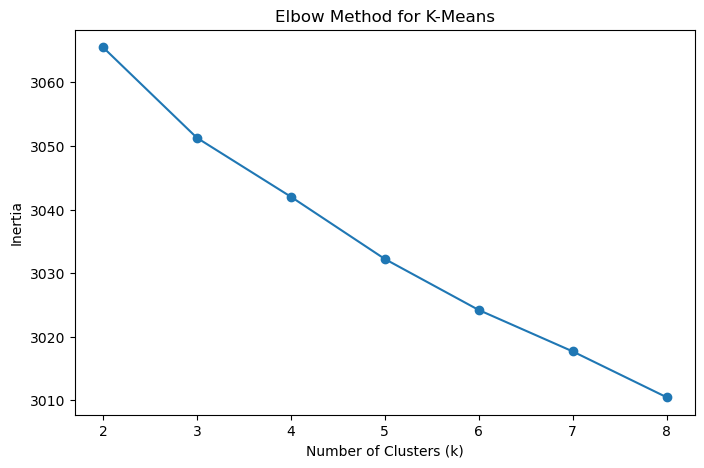

In [148]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

No clear elbow, but it seems like the inertia rounds out the most from `6 -> 7`. Let's take a look at our silhouette scores.

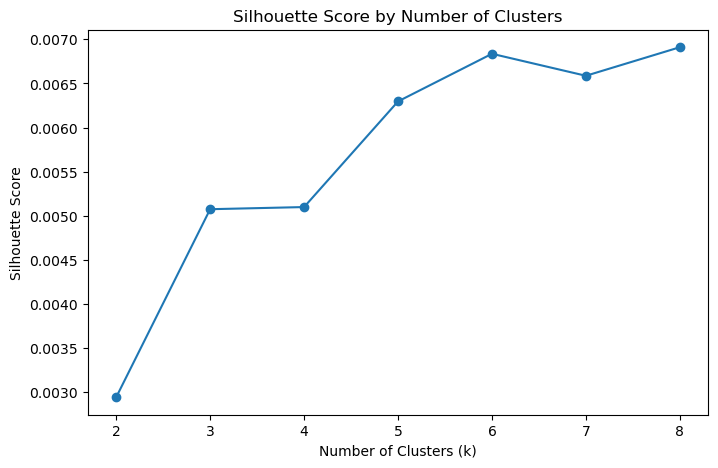

In [150]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.show()

This graph shows that `k = 8` has the greatest value in silhouette score at almost 0.070. There is a drop in score from `6 -> 7` as well.

Additionally, these values are still quite low (<0.01), meaning that there's a lot of overlap between the complaint themes/clusters. This is probably due to the fact that these reviews can have the same topics in the same review. However, the model only assigns one topic to a review. This is one of our limitations with this method.

### Testing of K Values

We'll test k values 6, 7, and 8 to see which ones yield more useful clusters.

#### k = 6

In [155]:
kmeans6 = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

phase2_cluster["Cluster_k6"] = kmeans6.fit_predict(X_tfidf_clean)

phase2_cluster["Cluster_k6"].value_counts().sort_index()

Cluster_k6
0      32
1     548
2     105
3     321
4    1377
5     752
Name: count, dtype: int64

In [156]:
terms = vectorizer.get_feature_names_out()

for cluster_num in range(kmeans6.n_clusters):
    
    centroid = kmeans6.cluster_centers_[cluster_num]
    
    top_indices = centroid.argsort()[-15:][::-1]
    
    top_terms = terms[top_indices]
    
    print(f"\nCluster {cluster_num}:")
    print(", ".join(top_terms))


Cluster 0:
baby, sweet baby, sweet, inc, baby inc, no sweet, no, deserves, say no, cdpr, sweat, sbi, partnering sweet, partnering, company

Cluster 1:
crashes, update, crashing, crash, every, time, fix, new, launch, even, no, unplayable, not, since, patch

Cluster 2:
cant, cant even, even, even launch, even load, load, launch, anymore, fix, still cant, even open, update, no, open, fixed

Cluster 3:
still, bugs, buggy, years, still buggy, many, many bugs, mess, even, not, release, years later, later, buggy mess, years still

Cluster 4:
not, no, boring, good, even, hours, fun, time, sbi, bad, trash, like, money, dlc, story

Cluster 5:
like, not, story, feels, really, world, good, even, no, feel, time, much, boring, still, cyberpunk


These findings show some semblance of topics. Let's outline them out here:

- [32 reviews] Cluster 0: Sweet Baby (`baby`, `sweet baby`, `inc`, `say no`, `company`, `studio`)
- [548 reviews] Cluster 1: Crashes (`crashes`, `crashing`, `every`, `cant even`, `start`)
- [105 reviews] Cluster 2: Launching/Loading Problems (`cant even`, `even launch`, `fix`, `still cant`, `even open`)
- [321 reviews] Cluster 3: Bugs (`bugs`, `buggy`, `bug`, `mess`, `buggy mess`)
- [1377 reviews] Cluster 4: Boring/Money/Pricing (`boring`, `trash`, `story`, `money`, `dlc`) 
- [752 reviews] Cluster 5: Boring Content (`boring`, `world`, `feels`) 

Just looking at the number of reviews in each cluster, we can see that it's unbalanced. We have a large amount of reviews in our Cluster 4 at 1377 reviews. I'm assuming that this means that these are ones that are more general.

A quick search reveals that the whole Sweet Baby topic refers to an unpopular hiring of [a figure from a diversity-focused consulting agency](https://www.reddit.com/r/OutOfTheLoop/comments/1b8b98w/whats_going_on_with_the_sweet_baby_inc_controversy/).
  
Let's try the other k values to see if they produce better results:

#### k = 7

Increasting the amount of clusters might be able to fix our problem of big clusters. 

In [160]:
kmeans7 = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

phase2_cluster["Cluster_k7"] = kmeans7.fit_predict(X_tfidf_clean)

phase2_cluster["Cluster_k7"].value_counts().sort_index()

Cluster_k7
0     123
1     631
2     258
3    1701
4      32
5     237
6     153
Name: count, dtype: int64

I guess not. But this means that these clusters are more specialized.

In [162]:
terms = vectorizer.get_feature_names_out()

for cluster_num in range(kmeans7.n_clusters):
    
    centroid = kmeans7.cluster_centers_[cluster_num]
    
    top_indices = centroid.argsort()[-20:][::-1]
    
    top_terms = terms[top_indices]
    
    print(f"\nCluster {cluster_num}:")
    print(", ".join(top_terms))


Cluster 0:
cant, sbi, cant even, even, cdpr, anymore, even load, no, load, still cant, fix, update, aesthetics resist, denfend rights, denfend, resist, resist sbi, interference, rights aesthetics, interference cdpr

Cluster 1:
like, not, story, feels, really, world, good, even, no, feel, time, cyberpunk, much, still, feels like, gameplay, way, city, main, bad

Cluster 2:
crashes, crashing, every, keeps, keeps crashing, time, crashes every, minutes, update, every time, fix, launch, no, tried, unplayable, even, new, crash, drivers, screen

Cluster 3:
not, no, even, update, time, hours, bugs, still, good, like, fix, dlc, fun, launch, new, crash, bad, money, patch, pc

Cluster 4:
baby, sweet baby, sweet, inc, baby inc, no sweet, no, deserves, say no, cdpr, sweat, sbi, partnering sweet, partnering, company, sb, ck, kf, fxxk, future

Cluster 5:
still, buggy, bugs, years, still buggy, mess, many, years later, buggy mess, later, release, years still, even, broken, many bugs, bugs still, still

These are more spread out topics:

- [123 reviews] Cluster 0: Loading Issues/Interference?(`even load`, `load`, `still cant`, `interference`, `interference cdpr`)
- [631 reviews] Cluster 1: Story (`story`, `gameplay`, `cyberpunk`, `main`, `bad`)
- [258 reviews] Cluster 2: Crashes (`crashes`, `crashing`, `unplayable`, `crash`)
- [1701 reviews] Cluster 3: Money/Updates (`update`, `bugs`, `fix`, `dlc`, `money`)
- [32 reviews] Cluster 4: Sweet Baby (`baby`, `sweet baby`, `baby inc`, `partnering sweet`)
- [237 reviews] Cluster 5: Bugs (`still buggy`, `buggy`, `buggy mess`, `bugs still`)
- [153 reviews] Cluster 6: Boring Content (`boring`, `story`, `long`, `scenes`)

We have a larger majority cluster now at 1701 for our Cluster 3. It seems that this is still relating to money but also just generally negative. When we choose our k value, we'll be able to look at it more closely.

#### k = 8

In [165]:
kmeans8 = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

phase2_cluster["Cluster_k8"] = kmeans8.fit_predict(X_tfidf_clean)

phase2_cluster["Cluster_k8"].value_counts().sort_index()

Cluster_k8
0      32
1      71
2    1495
3     294
4     363
5     641
6      95
7     144
Name: count, dtype: int64

We have some small clusters once again. Let's just check them out:

In [167]:
terms = vectorizer.get_feature_names_out()

for cluster_num in range(kmeans8.n_clusters):
    
    centroid = kmeans8.cluster_centers_[cluster_num]
    
    top_indices = centroid.argsort()[-15:][::-1]
    
    top_terms = terms[top_indices]
    
    print(f"\nCluster {cluster_num}:")
    print(", ".join(top_terms))


Cluster 0:
baby, sweet baby, sweet, inc, baby inc, no sweet, no, deserves, say no, cdpr, sweat, sbi, partnering sweet, partnering, company

Cluster 1:
buggy, still buggy, still, buggy mess, mess, buggy hell, years, buggy piece, hell, even, piece, years later, bugs, later, crashes

Cluster 2:
not, no, time, even, good, update, like, hours, fun, fix, bad, cdpr, dlc, sbi, bug

Cluster 3:
still, bugs, years, many, many bugs, not, even, release, broken, years still, bugs still, fixed, still not, unplayable, dlc

Cluster 4:
crashes, cant, even, update, every, launch, cant even, crash, time, no, load, crashes every, fix, tried, new

Cluster 5:
like, not, story, feels, world, really, good, even, feel, no, time, much, cyberpunk, still, way

Cluster 6:
crashing, keeps, keeps crashing, crashing every, without, without crashing, time, update, every, minutes, unplayable, fix, still, keep crashing, every minutes

Cluster 7:
boring, story, boring story, good, dialogue, not, like, hours, story boring


- [32 reviews] Cluster 0: Sweet Baby (`baby`, `sweet baby`, `baby inc`, `partnering sweet`)
- [71 reviews] Cluster 1: Bugs (`still buggy`, `buggy hell`, `buggy mess`, `buggy piece`)
- [1495 reviews] Cluster 2: Undetermined (`update`, `fun`, `dlc`, `bug`)
- [294 reviews] Cluster 3: Bugs (`bugs still`, `unplayable`, `dlc`, `release`)
- [363 reviews] Cluster 4: Crashes/Launching Issues (`crashes`, `cant even`, `launch`, `crashes every`)
- [641 reviews] Cluster 5: Story/World (`story`, `world`, `cyberpunk`)
- [95 reviews] Cluster 6: Crashes (`crashing`, `keeps crashing`, `without crashing`, `unplayable`)
- [144 reviews] Cluster 7: Content Issues (`boring`, `story`, `dialogue`, `gameplay`)

We have more fragmented clusters when `k = 8`. Our majority cluster *has* been reduced, but now it's looking much more general. Our Clusters 1 and 3 are quite similar to one another, as well as our Cluster 4 and 6. Otherwise, everything else does seem to be more fragmented.

#### Looking At Reviews at `k = 8`

I select `k = 6` as it had the best interpretability. `k = 7` had a new cluster that was incoherent whereas `k = 8` had a problem of splitting up issues that I might end up combining anyway. `k = 6` had the following themes that I was able to recognize:

0. Sweet Baby,
1. crashes,
2. launching/loading porblems,
3. bugs/DLC concerns,
4. Boring/Money/Pricing,
5. and boring content.

To confirm, I just wanted to look at some sample reviews from each topic. By looking closer at the reviews, we can see if we have to combine any of them.

##### Cluster 1: Crashes

This one had terms like `crashes`, `crashing`, `every`, `cant even`, `start`.

In [172]:
terms = vectorizer.get_feature_names_out()

cluster_num = 1
centroid = kmeans6.cluster_centers_[cluster_num]

top_indices = centroid.argsort()[-20:][::-1]
top_terms = terms[top_indices]

print(f"\nCluster {cluster_num} Terms:")
print(", ".join(top_terms))


Cluster 1 Terms:
crashes, update, crashing, crash, every, time, fix, new, launch, even, no, unplayable, not, since, patch, tried, keeps, pc, mods, minutes


In [173]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 1
]["Review"].sample(
    10,
    random_state=42
)

for review in sample:
    print("\n>", review)


> Trash game dosent even wanna  launch support is useless been trying to fix this game for 24 hours non stop and still crashes at launch FIX YOUR GAME

> Great game if it wouldn't crash or no clip every day.

> Wish i could've played. My PC meets the requirements but it wouldnt even open, the game kept crashing "flatline error" everytime I tried to play. I searched google and reddit to troubleshoot the problem but nothing worked. Seems to be a common issue for people. Sucks when games dont work, I just want to download and play not become geek squad tech support.

> would be great if it didn't crash upon launch since the latest patch nicely done

> would have been one of my favourite story games ive played in a long while as the story is genuinely special however for me the game is physically unplayable my game glitched and i became invulnerable rendering the game completely unfun forcing me to quit a couple of months ago as even editing the game files didnt work to fix it. attempted 

Confirmed that these reviews fall under general discussion about the game crashing. There are mentions of "crashes at launch", "wouldn't even open", and "wouldn't even open". 

We'll compare this with Cluster 2, which is also quite similar to this one.

##### Cluster 2: Launching/Loading Problems

This one had terms like `cant even`, `even launch`, `fix`, `still cant`, `even open`.

In [176]:
terms = vectorizer.get_feature_names_out()

cluster_num = 2
centroid = kmeans6.cluster_centers_[cluster_num]

top_indices = centroid.argsort()[-20:][::-1]
top_terms = terms[top_indices]

print(f"\nCluster {cluster_num} Terms:")
print(", ".join(top_terms))


Cluster 2 Terms:
cant, cant even, even, even launch, even load, load, launch, anymore, fix, still cant, even open, update, no, open, fixed, cant romance, im, save, time, crashing


In [177]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 2
]["Review"].sample(
    10,
    random_state=42
)

for review in sample:
    print("\n>", review)


> Booted the game after a long time, because apparently its fixed, i cant even start the game now, got bugged twice just in the difficulty selection.

> 50 hours in and having put up with hundreds of minor bugs i encountered one that just flat out breaks my game in an unrecoverable way - i cant open the phone/map/inventory/journal/fast travel. This issue has apparently been open for three years. :meatytears: guess i'll just pray for a patch?So they patched it and it fixed my save! And then it broke in exactly same way again a week later. :lunar2019laughingpig: i give up

> cant even load into the game

> Cant even tart it anymore after last update!! Running on a Lenovo with  i9 -13900HX and RTX4070 and 32 gig Ram... so its not the computer

> I cant denie I was warned, but I waited long enough and got the game cheap so I tried...some people said now it was a good game, well it is not, story is silly, bland, the I.A and bullets fights are ♥♥♥♥!! still has a few glitches, the city is no

These seem to be more general bugs and not being able to load in. Let's take a look at more samples:

In [179]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 2
]["Review"].sample(
    10,
    random_state=2
)

for review in sample:
    print("\n>", review)


> Game had a lot of potential. Played at inital release. Post fix and now. Game is still broken last update i cant even load my save files. I hope that CD projekt spends more time developing actual gameplay vs infinite Citiscape as QoL updates dont mean anything when your game runs like a single blade push mower

> have a problem with a sound glitch when im riding a car it get so anoying i cant play it anymore

> This game is stupid.  I cant even get past the advanced combat training even though I'm doing exactly as the instructions say.  Waste of time.

> cant even launch the game

> you cant kill kids

> cant cyber the punk

> Cant even play the game anymore,im on play it safe and right after I'm done waiting for the parade to start I get stuck and I've had to spend the last 2 hours finding a no clip mod and that doesn't even work

> I figured they'd have fixed the game by now, but now I'm unable to even launch the game...

> Could be a great game.... BUT IDK, because I still cant a

This one just made me laugh:

> cant cyber the punk

It seems that this cluster comes mostly from the "cant" word. It seems to be more "General Dissatisfaction".

##### Cluster 3: Bugs

This one had terms like `bugs`, `buggy`, `bug`, `mess`, `buggy mess`.

In [182]:
terms = vectorizer.get_feature_names_out()

cluster_num = 3
centroid = kmeans6.cluster_centers_[cluster_num]

top_indices = centroid.argsort()[-20:][::-1]
top_terms = terms[top_indices]

print(f"\nCluster {cluster_num} Terms:")
print(", ".join(top_terms))


Cluster 3 Terms:
still, bugs, buggy, years, still buggy, many, many bugs, mess, even, not, release, years later, later, buggy mess, years still, bugs still, broken, unplayable, crashes, glitches


In [183]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 3
]["Review"].sample(
    10,
    random_state=42
)

for review in sample:
    print("\n>", review)


> So many bugs still...

> nah men, been almost 3 years since release and this thing is still infected with bugs. Kinda ruined my experience.

> This game still sucks lmao

> It's finally what should have released way back. It's still not worth the full asking price since it's not truely an RPG. It's still a hollow, lifeless sandbox akin to GTA since there are no choices that can shape your story and you have no influence in the world. The "RPG" comes from just leveling and stats. It has no modding community around to add longevity and diversity to it via modding like Bethesda's games.Most of the major bugs are gone but the AI is still broken most of the time. NPCs still collide together and will often get stuck due to pathing issues. Some textures are still completely busted and the most annoying one still isn't fixed. Smoke and gas are still pixelated even if DLSS/FSR/XeSS is turned off.It's disappointing that the 2.0 release alongside Phantom Liberty marks the end of official suppo

These samples do report on general bugs and dissatisfaction as well. Let's confirm with another sample as this one is big as well:

In [185]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 3
]["Review"].sample(
    10,
    random_state=2
)

for review in sample:
    print("\n>", review)


> How is this garbage still not run-able.

> This game is super boring and the graphics are mid. Not worth the money still even years later. I regret this purchase

> Finally in a playable state after 3 years - releases a dlc and breaks the game again. Unplayable nightmare full of bugs

> the game is still unplayable... I wish it wasn't too late to get refunded for this crap

> A lot of bugs. Better than it was, but still buggy as hell.Base game is woke, but in acceptable amount if you steer away from making fem V with male organs and homosexual romances. Phantom Liberty on the other hand went full libtard-feminist way. If you have problems with woke ideology being pushed everywhere from TV to videogames, do not buy this game, it is clear CDPR changed in latest years, and their incoming games may or rather will be even more woke.#woke #bugs

> Still bad, still glitchy. Story is soooooo dumb. Don't wait hoping the end will tie it all up, it's just disappointing CDPR is dead to me :(

>

More mentions of being unplayable and unrunnable. This relates to the next cluster as well. We are seeing the low silhouette score at hand here.

##### Cluster 4: Boring/Money/Pricing

This one had terms like `boring`, `trash`, `story`, `money`, `dlc`.

In [188]:
terms = vectorizer.get_feature_names_out()

cluster_num = 4
centroid = kmeans6.cluster_centers_[cluster_num]

top_indices = centroid.argsort()[-20:][::-1]
top_terms = terms[top_indices]

print(f"\nCluster {cluster_num} Terms:")
print(", ".join(top_terms))


Cluster 4 Terms:
not, no, boring, good, even, hours, fun, time, sbi, bad, trash, like, money, dlc, story, bug, never, much, buy, make


In [189]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 4
]["Review"].sample(
    10,
    random_state=42
)

for review in sample:
    print("\n>", review)


> Apparently the newest version has rendered the game completely unplayable, so good job CDPR, this is a complete waste of money...

> stupid continuous crush

> I finished the requirements for a quest but it didnt register. enemy is lying on the ground and the quest is telling me i havent found her yet.

> I really don't get the draw of this game.  It was a mediocre FPS with a poorly-balanced hacking mechanic.  With "contagion" you can kill a whole building full of people from a bench outside on the street, and that power doesn't get any less useful throughout the game.  The characters weren't as engaging as I'd hoped, and Keanu is a TERRIBLE voice actor.  I've been playing FPS games since I got DOOM for christmas in the early 90s, and this one won't be reinstalled (though I played Quake3 yesterday).

> Boring. Gameplay is basically hit x a bunch of times to advance dialog, kill some enemies and repeat over and over

> go to hell LGBTQ+! go to hell Mary kenney! ♥♥♥♥ you!

> Overrated

As this is the majority cluster, we do find that these reviews are more general. Lets take a look at another sample:

In [191]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 4
]["Review"].sample(
    10,
    random_state=2
)

for review in sample:
    print("\n>", review)


> Made by a company that fired %9 of its workers only in 2023 on a whim. Their game appears to be anti-corporate and anti-capitalist, while in real life they make profit off the sweat of their workers, whom they send back to the industrial reserve army whenever their rate of profit threatens to decline, and from the gullible consumers, who are easily tricked into buying "the next big thing" with a few screenshots or videos. How am I supposed to take your story seriously while in real life you're the antithesis of everything your game appears criticize?In short, this is a product that embodies the typical bourgeois hypocrisy, but in the realm of video game industry.

> Managed to stay spoiler free up until i purchased this game last month. Game is bug free and runs great.Story is VERY slow paced for me. I put about 16 hrs in it and it just seemed like alot of busy work. Just not my cup of tea I guess. Not a fan of the first person either.

> Worst game i have ever played. Lot of bug ec

It seems that there's only a small amount of money/price-related reviews. We'll rename this one to General Dissatisfaction.

##### Cluster 5: Content Issues

This one had terms like `boring`, `world`, `story`.

In [194]:
terms = vectorizer.get_feature_names_out()

cluster_num = 5
centroid = kmeans6.cluster_centers_[cluster_num]

top_indices = centroid.argsort()[-20:][::-1]
top_terms = terms[top_indices]

print(f"\nCluster {cluster_num} Terms:")
print(", ".join(top_terms))


Cluster 5 Terms:
like, not, story, feels, really, world, good, even, no, feel, time, much, boring, still, cyberpunk, gameplay, bad, way, make, city


In [195]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 5
]["Review"].sample(
    10,
    random_state=42
)

for review in sample:
    print("\n>", review)


> Where to start. Well first off I do like this game and want to like it, but it makes it difficult for me to come back to it sometimes. Gameplay and story are prem, but there are still tons of major glitches i keep running into. First major one is the map just not loading or taking like five years to load everything in and sometime i just fall through a unloaded chunk of the map (note i was all going fast). Second glitch and it only happened in the begining of the dlc is that the lighting will just disappear and everything will be dark (Note just had to restart to get it back to normal). Now to give credit to the devs it use to be alot worse.All of these are minor inconveniences, but are prominent 2 to 3 years after the game has  released still. tldr: Game gud but bugs Make ME ANGY >:(

> I need to play it with the new expansion however, honestly I was disappointed how on rails this was. Cyberpunk is like D&D or Shadowrun etc. Its an open world with endless possibilities with a ton o

These reviews seem to be the more lengthy ones that go into further detail about their experiences. Some reviews mention suggestions on what to improve but some dive into more detail about their experiences with story & characters and insights about the game: 

> ...they went for lame style over meaningful substance.

>  This was nothing more then a standard fair FPS missing the depth.

> Story didn't even make sense

The theme does encompass quite a bit of aspects about the game, but generally addresses the content of the game.

##### Cluster 0: Sweet Baby

This cluster just had 32 reviews all mentioning Sweet Baby.

In [198]:
sample = phase2_cluster[
    phase2_cluster["Cluster_k6"] == 0
]["Review"].sample(
    10,
    random_state=42
)

for review in sample:
    print("\n>", review)


> Fxck Sweet Baby Inc! I cannot trust any future games from CDPR as long as SBI is involved

> Game is awesome.Sweet Baby Inc is not. Don't let Cyberpunk 2 be ruined by them.

> SWEET BABY? F**K OFF!!

> Sweet Baby  C N M

> ♥♥♥♥ you Sweet Baby and CD PROJEKT

> CDPR joining the sweet baby inc. cult. Do not support this company.

> Sweet Baby deserves it.CDPR R.I.P.

> Marry kenny sweet baby 👎👎👎🤮

> Sweet baby to say no!!!!!

> NO sweat baby!


There are quite a few we saw in our previous clusters that also relate to this issue, with terms like 'sbi' or when they try to mention "LGBTQ". It's still a topic nonetheless.

- [32 reviews] Cluster 0: Sweet Baby (`baby`, `sweet baby`, `inc`, `say no`, `company`, `studio`)
- [548 reviews] Cluster 1: Crashes (`crashes`, `crashing`, `every`, `cant even`, `start`)
- [105 reviews] Cluster 2: Launching/Loading Problems (`cant even`, `even launch`, `fix`, `still cant`, `even open`)
- [321 reviews] Cluster 3: Bugs/DLC concerns (`bugs`, `buggy`, `bug`, `mess`, `buggy mess`)
- [1377 reviews] Cluster 4: Boring/Money/Pricing (`boring`, `trash`, `story`, `money`, `dlc`) 
- [752 reviews] Cluster 5: Boring Content (`boring`, `world`, `feels`) 

##### Summary + Assignment of Themes

Overall, it was decided that Cluster 1 and 4 should just be merged together, while the other ones could stay. We have the following themes for each of the clusters:

0. Sweet Baby
1. Crashes and Performance
2. General Dissatisfaction ('cant' cluster)
3. Bugs/Buggy Experience
4. General Dissatisfaction
5. Content Issues

Let's just assign a name to our dataframe for our comparisons later:

In [202]:
# Rename our chosen cluster and drop the other ones:

phase2_cluster = phase2_cluster.rename(columns={"Cluster_k6": "Cluster"})
phase2_cluster = phase2_cluster.drop(columns=["Cluster_k7", "Cluster_k8"])

# Assign names to the clusters

cluster_names = {
    0: "Sweet Baby",
    1: "Crashes and Performance",
    2: "General Dissatisfaction",
    3: "Bugs/Buggy Experience",
    4: "General Dissatisfaction",
    5: "Content Issues"
}

phase2_cluster["Theme"] = phase2_cluster["Cluster"].map(cluster_names)

### Comparison

> After creating the groups, compare them using the number of reviews, percentage of negative reviews, median player playtime, review length, helpfulness votes, purchase status, and reviewer experience. Use these comparisons to determine which complaint themes should receive the highest priority.

Let's go ahead with the comparisons between the themes. Firstly, let's get a check of our counts for each theme:

In [205]:
theme_counts = (
    phase2_cluster
    .groupby("Theme")
    .size()
    .sort_values(ascending=False)
)

print(theme_counts)

Theme
General Dissatisfaction    1482
Content Issues              752
Crashes and Performance     548
Bugs/Buggy Experience       321
Sweet Baby                   32
dtype: int64


We do have the most reviews of General Dissatisfaction at 1482, but it doesn't mean that it's the highest priority right away. We did see that there were reviews in the sample we got that had words that could have went into the other themes but didn't necessarily get caught by the model. Because of this, the findings from this cluster/theme won't hold as much weight.

#### Percentage of Negative Reviews

In [208]:
theme_summary = (
    phase2_cluster
    .groupby("Theme")
    .size()
    .reset_index(name="Review Count")
)

theme_summary["Percentage"] = (
    theme_summary["Review Count"]
    / len(phase2_cluster)
    * 100
)

print(theme_summary)

                     Theme  Review Count  Percentage
0    Bugs/Buggy Experience           321   10.239234
1           Content Issues           752   23.987241
2  Crashes and Performance           548   17.480064
3  General Dissatisfaction          1482   47.272727
4               Sweet Baby            32    1.020734


We have the least amount of reviews in Sweet Baby at `1.0%`. Our second largest percentage comes from the Content Issues theme at `23.9%`.

#### Median Player Playtime

We'll be getting the median player playtime next, as outlined by the task.

In [212]:
playtime_summary = (
    phase2_cluster
    .groupby("Theme")["Hours Played"]
    .median()
    .reset_index(name="Median Hours Played")
)

print(playtime_summary)

                     Theme  Median Hours Played
0    Bugs/Buggy Experience                51.60
1           Content Issues                50.10
2  Crashes and Performance                63.60
3  General Dissatisfaction                44.55
4               Sweet Baby               117.55


We have a clear increase in median hours played in our Sweet Baby cluster. This might be because there's less reviews in this cluster, so it's more varied. The next is Crashes and Performance though with a median of 63.60.

#### Review Length

We'll be getting review length from the original `Review` rather than `Clean Review`. We calculated these already but we made a new dataframe so we'll just do it again:

In [216]:
phase2_cluster["Review Length"] = (
    phase2_cluster["Review"]
    .fillna("")
    .str.split()
    .str.len()
)

review_length_summary = (
    phase2_cluster
    .groupby("Theme")["Review Length"]
    .median()
    .reset_index(name="Median Review Length")
)

print(review_length_summary)

                     Theme  Median Review Length
0    Bugs/Buggy Experience                  26.0
1           Content Issues                 137.0
2  Crashes and Performance                  39.0
3  General Dissatisfaction                  24.0
4               Sweet Baby                   5.5


We see an increase in median review length in the `Content Issues` theme. This makes sense as these reviews tends to be longer as they express more of their insights and complaints. We have the least in `Sweet Baby` as they usually just talk about that in their reviews.

#### Helpfulness Votes

By looking at our helpfulness votes, we can also take a look what reviews other people find the most helpful. We are assuming that users use the Helpful Votes as an actual helpful vote button rather than a general "like" button. We'll take a look at the Q1, Median, Q3, and the Mean for each group.

In [220]:
helpful_summary = (
    phase2_cluster
    .groupby("Theme")["Voted Helpful"]
    .agg(
        Q1_Helpful_Votes=lambda x: x.quantile(0.25),
        Median_Helpful_Votes="median",
        Q3_Helpful_Votes=lambda x: x.quantile(0.75),
        Average_Helpful_Votes="mean"
    )
    .reset_index()
)

print(helpful_summary)

                     Theme  Q1_Helpful_Votes  Median_Helpful_Votes  \
0    Bugs/Buggy Experience               0.0                   1.0   
1           Content Issues               0.0                   1.0   
2  Crashes and Performance               0.0                   1.0   
3  General Dissatisfaction               0.0                   0.0   
4               Sweet Baby               0.0                   1.0   

   Q3_Helpful_Votes  Average_Helpful_Votes  
0               2.0               1.314642  
1               3.0               3.539894  
2               2.0               2.611314  
3               2.0               2.069501  
4               5.0               3.750000  


We have the same values for the Q1 and most of the median. `Voted Helpful` *is* an integer and is heavily right-skewed, so this isn't surprising. The 0 in General Dissatisfaction comes from the massive amount of reviews in this cluster. In our Q3 and the average, we do see an increase in the `Content Issues` cluster with 3 and 3.5 respectively, while the others stay at around 1 to 2. The `Sweet Baby` cluster has the most out of all, but this may be due to the fact that there's so few reviews in the cluster.

#### Purchase Status

We found that our closest way to measure "purchase status", through `Received for Free`, doesn't tell us too much. It would be different if we had more useful information like refunded or was bought on sale. Let's just check it anyway just in case:

In [224]:
purchase_summary = (
    phase2_cluster
    .groupby("Theme")["Received for Free"]
    .mean()
    .mul(100)
    .reset_index(name="Received Free (%)")
)

print(purchase_summary)

                     Theme  Received Free (%)
0    Bugs/Buggy Experience           0.623053
1           Content Issues           0.797872
2  Crashes and Performance           0.547445
3  General Dissatisfaction           1.012146
4               Sweet Baby           0.000000


We'll omit this from the final comparison as I have decided these are negligible values (<1% change).

#### Reviewer Experience

Like mentioned before, we'll use `Hours Played` as a proxy to show reviewer/player experience with the game. We will bin the hours based on [this information](https://howlongtobeat.com/game/2127) and compare:

In [364]:
# Bin the groupings

phase2_cluster["Experience Group"] = pd.cut(
    phase2_cluster["Hours Played"],
    bins=[-1, 10, 30, 100, float("inf")],
    labels=[
        "0-10 hours", # new players, just got the game
        "10-30 hours", # played through the game / finished main story
        "30-70 hours", # generally an intermediate player, gone through side story + more
        "100+ hours" # heavy player of the game, completionist, exploration, etc.
    ]
)

experience_theme = pd.crosstab(
    phase2_cluster["Theme"],
    phase2_cluster["Experience Group"],
    normalize="index"
) * 100

print(experience_theme)

Experience Group         0-10 hours  10-30 hours  30-70 hours  100+ hours
Theme                                                                    
Bugs/Buggy Experience     19.626168    15.576324    32.398754   32.398754
Content Issues            15.558511    21.010638    34.973404   28.457447
Crashes and Performance   18.978102    13.686131    32.846715   34.489051
General Dissatisfaction   25.033738    17.071525    30.634278   27.260459
Sweet Baby                12.500000     9.375000    25.000000   53.125000


Across these themes, players with more than 30 hours are the ones who write most of the reviews, suggesting that many of these issues comes from players who have spent a long time in the game already rather than new players. The Buggy Experience, as well as the Performance issues are more prominent with the experienced players, with roughly 2/3rds of the reviews in each theme having more than 30 hours of playtime.

### Summary / Final Comparison

After splitting up the reviews within the last 10 months into 6 different clusters, we initially found the following themes:

- [32 reviews] Cluster 0: Sweet Baby (`baby`, `sweet baby`, `inc`, `say no`, `company`, `studio`)
- [548 reviews] Cluster 1: Crashes (`crashes`, `crashing`, `every`, `cant even`, `start`)
- [105 reviews] Cluster 2: Launching/Loading Problems (`cant even`, `even launch`, `fix`, `still cant`, `even open`)
- [321 reviews] Cluster 3: Bugs (`bugs`, `buggy`, `bug`, `mess`, `buggy mess`)
- [1377 reviews] Cluster 4: Boring/Money/Pricing (`boring`, `trash`, `story`, `money`, `dlc`) 
- [752 reviews] Cluster 5: Boring Content (`boring`, `world`, `feels`)

After examining the different reviews within these clusters, I had decided to change them into the following named themes:

0. Sweet Baby
1. Crashes and Performance
2. General Dissatisfaction ('cant' cluster)
3. Bugs/Buggy Experience
4. General Dissatisfaction
5. Content Issues

*Note: Cluster 2 was mostly generalized as it latched onto the 'cant' keyword, leading to Cluster 2 and 4 being combined.*

We have the following final counts:

- General Dissatisfaction: `1482`
- Content Issues: `752`
- Crashes and Performance:`548`
- Bugs/Buggy Experience: `321`
- Sweet Baby: `32`*

*Note: The `Sweet Baby` cluster isn't quite **actionable** as it mainly is just a collection of complaints against an unpopular company/group the company is affiliated with.*

In [332]:
theme_summary = (
    phase2_cluster
    .groupby("Theme")
    .agg(
        Review_Count=("Review", "size"),
        Median_Hours=("Hours Played", "median"),
        Median_Review_Length=("Review Length", "median"),
        Median_Helpful_Votes=("Voted Helpful", "median"),
    )
    .reset_index()
)

theme_summary["Negative_Review_Pct"] = (
    theme_summary["Review_Count"]
    / len(phase2_cluster)
    * 100
)

theme_summary = theme_summary[
    [
        "Theme",
        "Review_Count",
        "Negative_Review_Pct",
        "Median_Hours",
        "Median_Review_Length",
        "Median_Helpful_Votes",
    ]
]

print(theme_summary)

                     Theme  Review_Count  Negative_Review_Pct  Median_Hours  \
0    Bugs/Buggy Experience           321            10.239234         51.60   
1           Content Issues           752            23.987241         50.10   
2  Crashes and Performance           548            17.480064         63.60   
3  General Dissatisfaction          1482            47.272727         44.55   
4               Sweet Baby            32             1.020734        117.55   

   Median_Review_Length  Median_Helpful_Votes  
0                  26.0                   1.0  
1                 137.0                   1.0  
2                  39.0                   1.0  
3                  24.0                   0.0  
4                   5.5                   1.0  


### Final Recommendation

Based on the clustering and comparison of the recent negative reviews, Kosima Production should prioritize three areas: 

1. **boring or unsatisfying game content**, represented by the `Content Issues` cluster,
2. **crashes and difficulty launching or running the game**, represented by the `Crashes and Performance` cluster,
3. and **persistent bugs and a generally buggy/unfinished experience**, represented by the (`Bugs/Buggy Experience` cluster).

Boring or unsatisfying game content was the largest, most interpretable, complaint theme, being approximately 24% of the negative-review sample. Reviews in this cluster has much longer reviews, with a median length of 137 words compared to the 24-39 words for the other actionable themes. This suggests that players have a lot to say about their dissatisfaction with the game's content, making it important to investigate more thoroughly.

Crashes and difficulty launching or running the game should be another priority, as they account for approximately 17.5% of negative reviews. This theme has the highest median playtime at 63.6 hours, showing that these problems affect experienced players just as much as newer players. Because crashes and launch problems are something that QA testing and technical work can improve on, this theme should get some attention as well.

Persistent bugs and a generally buggy/unfinished experience represented another 10.2% of negative reviews. The cluster had terms like `bugs`, `buggy`, `buggy mess`, and `unfinished`, making it a pretty clear technical complaint category. Around 65% of reviewers in this theme had more than 30 hours of playtime, suggesting that these issues continue to affect players after having some substantial experience with the game.

Overall, the findings suggest that Kosima Production should focus on improving the quality and depth of game content (`Content Issues`) while also addressing technical problems that players run into, more specifically crashes, launch issues, (`Crashes and Performance`) and recurring bugs (`Bugs/Buggy Experience`). These concerns are more actionable than the broad `General Dissatisfaction` cluster and are supported by substantial numbers of recent negative reviews.